<a href="https://colab.research.google.com/github/Al-okPharmaTech/AI.ok-Diabetes-Project/blob/main/AI_ok.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# This link brings the data from the internet directly to your notebook
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Pedigree', 'Age', 'Outcome']

# This reads the data
df = pd.read_csv(url, names=names)

# This shows the first 5 patients
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


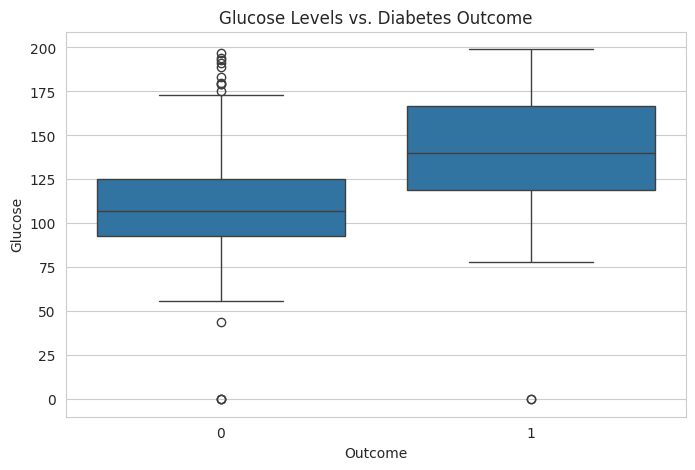

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# This creates a 'Box Plot' to show Glucose levels for Healthy (0) vs Diabetic (1)
plt.figure(figsize=(8,5))
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.title('Glucose Levels vs. Diabetes Outcome')
plt.show()

In [ ]:
# 1. Defining the 'Questions' (Features)
X = df.drop('Outcome', axis=1)

# 2. Defining the 'Answer' (Target)
y = df['Outcome']

# 3. Printing the results to check
print("Features (X) are:", X.columns.tolist())
print("Target (y) is: Outcome")

Features (X) are: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Pedigree', 'Age']
Target (y) is: Outcome


In [ ]:
# 1. Importing the 'Splitter' tool
from sklearn.model_selection import train_test_split

# 2. Doing the actual split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Checking the size of our piles
print("Patients for Training (Study):", X_train.shape[0])
print("Patients for Testing (Exam):", X_test.shape[0])

Patients for Training (Study): 614
Patients for Testing (Exam): 154


In [ ]:
from sklearn.linear_model import LogisticRegression

# 1. Create the AI brain
model = LogisticRegression(max_iter=1000)

# 2. Let the AI study the training data (The Training Step)
model.fit(X_train, y_train)

print("Brain is trained and ready!")

Brain is trained and ready!


In [ ]:
from sklearn.metrics import accuracy_score

# 1. The AI takes the exam (Guessing the outcomes for X_test)
predictions = model.predict(X_test)

# 2. Comparing the AI's guesses to the REAL answers (y_test)
score = accuracy_score(y_test, predictions)

print(f"Final Exam Accuracy: {score * 100:.2f}%")

Final Exam Accuracy: 74.68%


In [ ]:
import numpy as np

# 1. Defining a 'New Patient' (Example: High Glucose, High BMI)
# [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, Pedigree, Age]
new_patient = np.array([[2, 180, 75, 20, 0, 38.5, 0.5, 45]])

# 2. Asking the AI for a diagnosis
prediction = model.predict(new_patient)

# 3. Showing the result
if prediction[0] == 1:
    print("AI Diagnosis: Diabetic (High Risk)")
else:
    print("AI Diagnosis: Healthy (Low Risk)")

AI Diagnosis: Diabetic (High Risk)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd

# 1. Create a "tagged" patient using a Dictionary
new_patient_pro = pd.DataFrame([[2, 180, 75, 20, 0, 38.5, 0.5, 45]],
                               columns=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Pedigree', 'Age'])

# 2. Even if we scrambled the order, Pandas keeps the names attached!
# (The AI will now match the names correctly)
prediction = model.predict(new_patient_pro)

print("AI Diagnosis using 'Tagged' Data:", "Diabetic" if prediction[0] == 1 else "Healthy")

AI Diagnosis using 'Tagged' Data: Diabetic


In [ ]:
# 1. Asking for the probability instead of just a 0 or 1
probability = model.predict_proba(new_patient)

# 2. Extracting the chance of being Diabetic (the second number in the result)
diabetic_chance = probability[0][1] * 100

print(f"The AI is {diabetic_chance:.2f}% sure this patient is Diabetic.")

The AI is 90.18% sure this patient is Diabetic.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
# 1. Asking for the probability instead of just a 0 or 1
probability = model.predict_proba(new_patient_pro)

# 2. Extracting the chance of being Diabetic (the second number in the result)
diabetic_chance = probability[0][1] * 100

print(f"The AI is {diabetic_chance:.2f}% sure this patient is Diabetic.")

The AI is 90.18% sure this patient is Diabetic.


In [ ]:
# 1. Grabbing the very first patient (Row 0) from the original data
real_patient = X.iloc[[0]]

# 2. Seeing the real answer for this patient
real_answer = y.iloc[0]

# 3. Asking the AI to guess for this specific real person
prediction = model.predict(real_patient)

print(f"Real Patient Data:\n{real_patient}")
print(f"\nActual Diagnosis in Dataset: {real_answer}")
print(f"AI Prediction: {prediction[0]}")

Real Patient Data:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   

   Pedigree  Age  
0     0.627   50  

Actual Diagnosis in Dataset: 1
AI Prediction: 1


In [ ]:
# 1. Grabbing the very first patient (Row 0) from the original data
real_patient = X.iloc[[0]]

# 2. Seeing the real answer for this patient
real_answer = y.iloc[0]

# 3. Asking the AI to guess for this specific real person
prediction =  model.predict_proba(real_patient)

print(f"Real Patient Data:\n{real_patient}")
print(f"\nActual Diagnosis in Dataset: {real_answer}")
print(f"AI Prediction: { probability[0][1] * 100}")

Real Patient Data:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   

   Pedigree  Age  
0     0.627   50  

Actual Diagnosis in Dataset: 1
AI Prediction: 90.17652100927207


In [ ]:
# 1. Get the 'weights' (coefficients) from the trained model
importance = model.coef_[0]

# 2. Create a table to show Feature vs. Importance
feature_ranks = pd.DataFrame({'Metric': X.columns, 'Weight': importance})

# 3. Sort them from highest to lowest
feature_ranks = feature_ranks.sort_values(by='Weight', ascending=False)

print(feature_ranks)

          Metric    Weight
6       Pedigree  0.626718
5            BMI  0.102607
0    Pregnancies  0.064373
7            Age  0.037095
1        Glucose  0.034095
3  SkinThickness  0.003291
4        Insulin -0.001803
2  BloodPressure -0.013879


/tmp/ipykernel_20042/3299500340.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Weight', y='Metric', data=feature_ranks, palette='viridis')


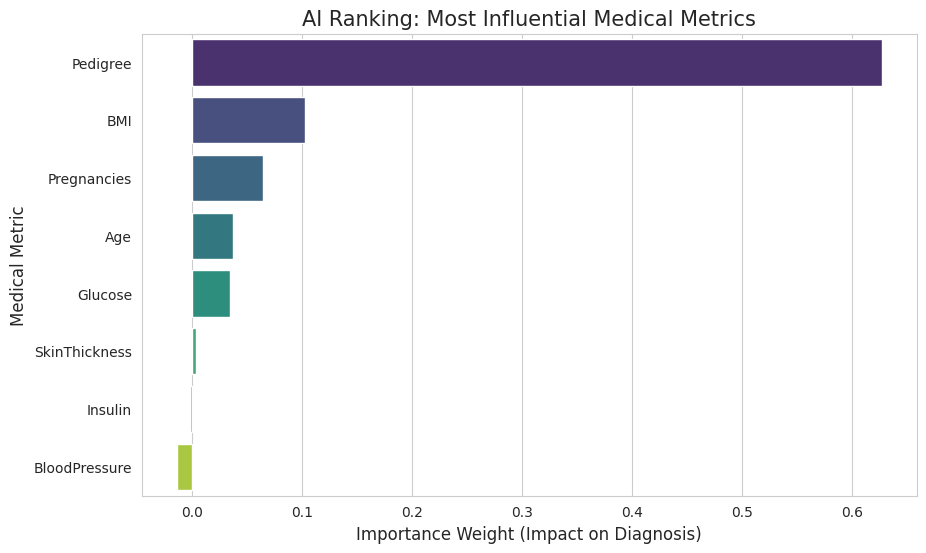

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setting the size and style
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# 2. Creating the Bar Chart
# We use the 'feature_ranks' table we just made
sns.barplot(x='Weight', y='Metric', data=feature_ranks, palette='viridis')

# 3. Adding professional labels
plt.title('AI Ranking: Most Influential Medical Metrics', fontsize=15)
plt.xlabel('Importance Weight (Impact on Diagnosis)', fontsize=12)
plt.ylabel('Medical Metric', fontsize=12)

# 4. Displaying the chart
plt.show()

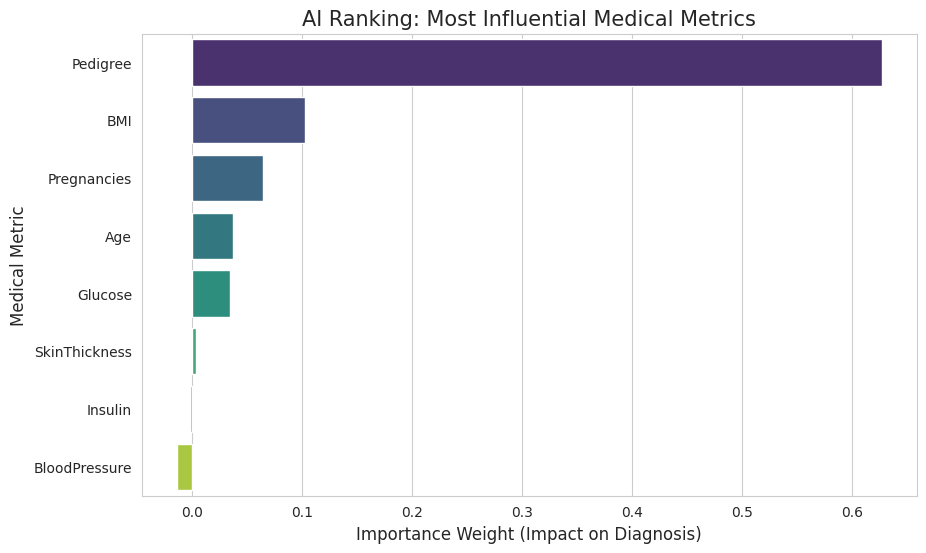

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setting the size and style
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# 2. Creating the Bar Chart
# We use the 'feature_ranks' table we just made
# Updated version that follows the new rules:
sns.barplot(x='Weight', y='Metric', data=feature_ranks, hue='Metric', palette='viridis', legend=False)

# 3. Adding professional labels
plt.title('AI Ranking: Most Influential Medical Metrics', fontsize=15)
plt.xlabel('Importance Weight (Impact on Diagnosis)', fontsize=12)
plt.ylabel('Medical Metric', fontsize=12)

# 4. Displaying the chart
plt.show()

In [ ]:
import joblib

# 1. Save the model to a file
joblib.dump(model, 'diabetes_model_v1.pkl')

print("Success! Your AI 'Brain' is now a file named 'diabetes_model_v1.pkl'")

Success! Your AI 'Brain' is now a file named 'diabetes_model_v1.pkl'


In [ ]:
import joblib
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Get the exact column names in order (Fixes the 'Scrambled' issue)
column_names = list(X.columns)
joblib.dump(column_names, 'columns.pkl')

# 2. Scale the data and train (Fixes the 'Scaler' issue)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # Using all X to make the scaler strong
model.fit(X_scaled, y)

# 3. Save everything (Fixes the 'Repeat Writing' issue)
joblib.dump(model, 'diabetes_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("All 3 issues resolved! Download: diabetes_model.pkl, scaler.pkl, and columns.pkl")

All 3 issues resolved! Download: diabetes_model.pkl, scaler.pkl, and columns.pkl
